<a href="https://colab.research.google.com/github/aman8122/data-science-Assignments/blob/main/week2_Aman_sain__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
from google.colab import files # This lia

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (4).csv


**Import** **libraries**

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

**load dataset**

In [157]:
ev_df=pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [158]:
ev_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [159]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


**Data preprocessing** **and** **Exploratory data analysis**


Check missing value

In [160]:
ev_df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


check duplicate value

In [161]:
print(ev_df.duplicated().sum())

0


In [162]:
num_cols = ev_df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')

starts summery and outlier detection

In [163]:
ev_df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


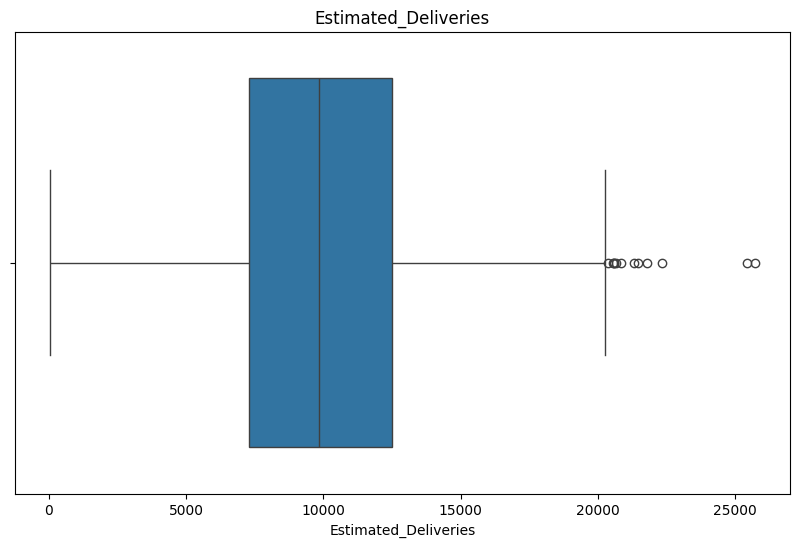

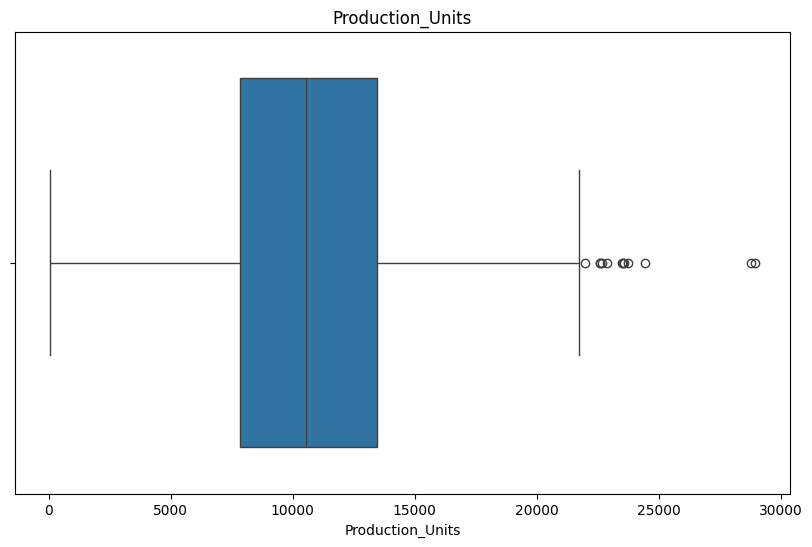

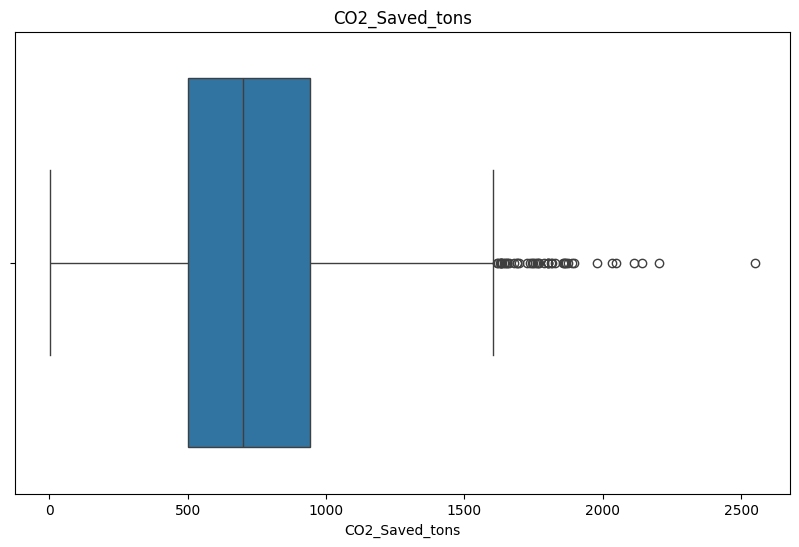

In [164]:
c=["Estimated_Deliveries","Production_Units","CO2_Saved_tons"]
for i in c:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=ev_df[i])
  plt.title(i)
  plt.show()


In [165]:
for col in c:

  Q1=ev_df[col].quantile(0.25)
  Q3=ev_df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  ev_df[col]=np.where(ev_df[col]<lower,lower,ev_df[col])
  ev_df[col]=np.where( ev_df[col]>upper,upper,ev_df[col])

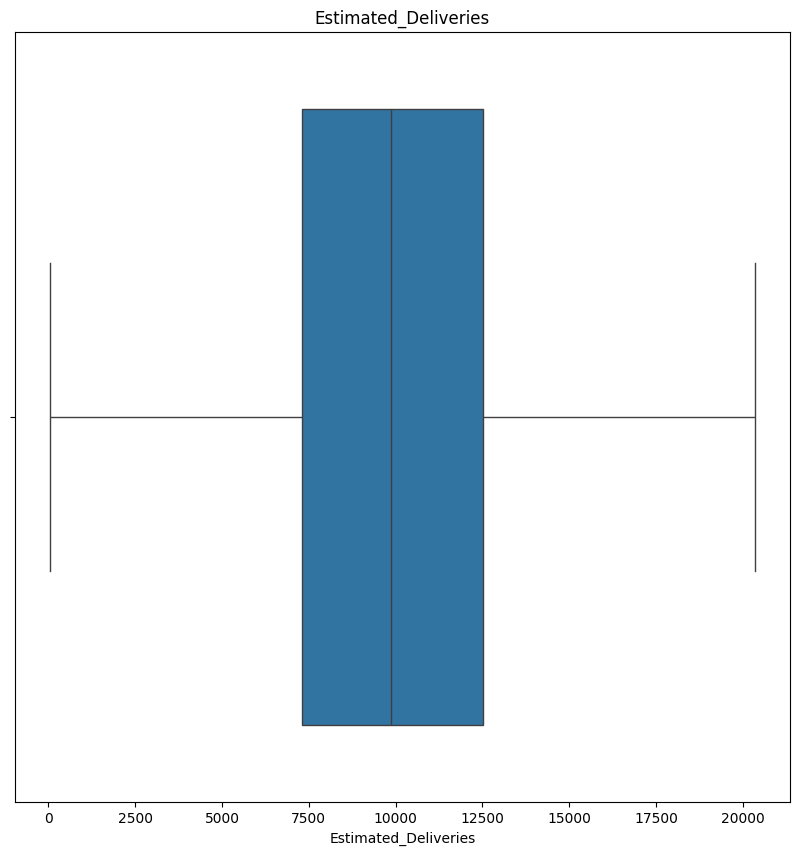

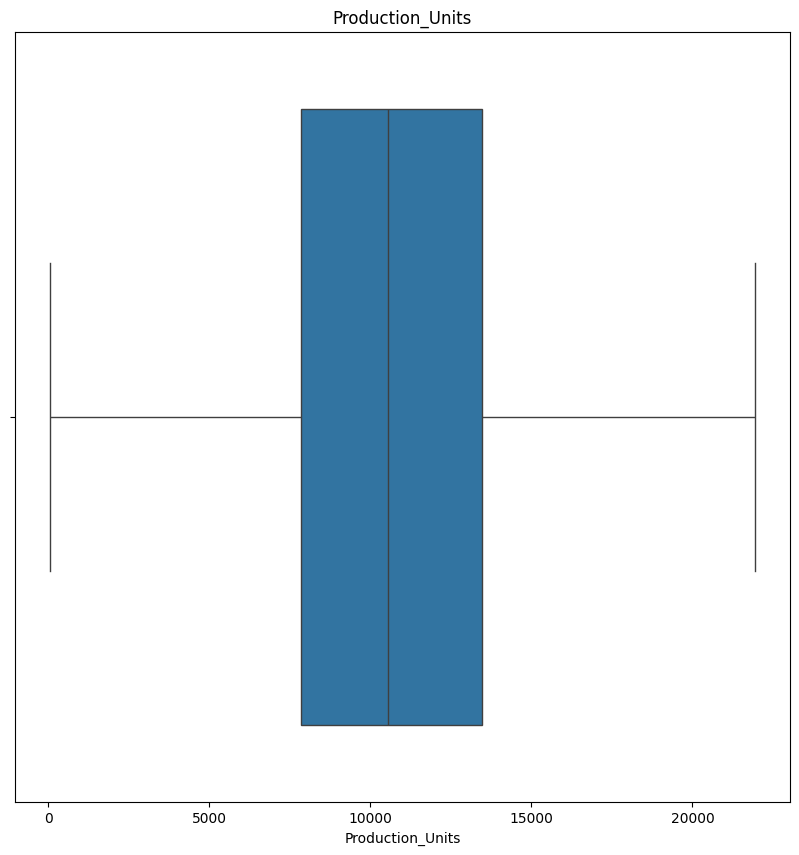

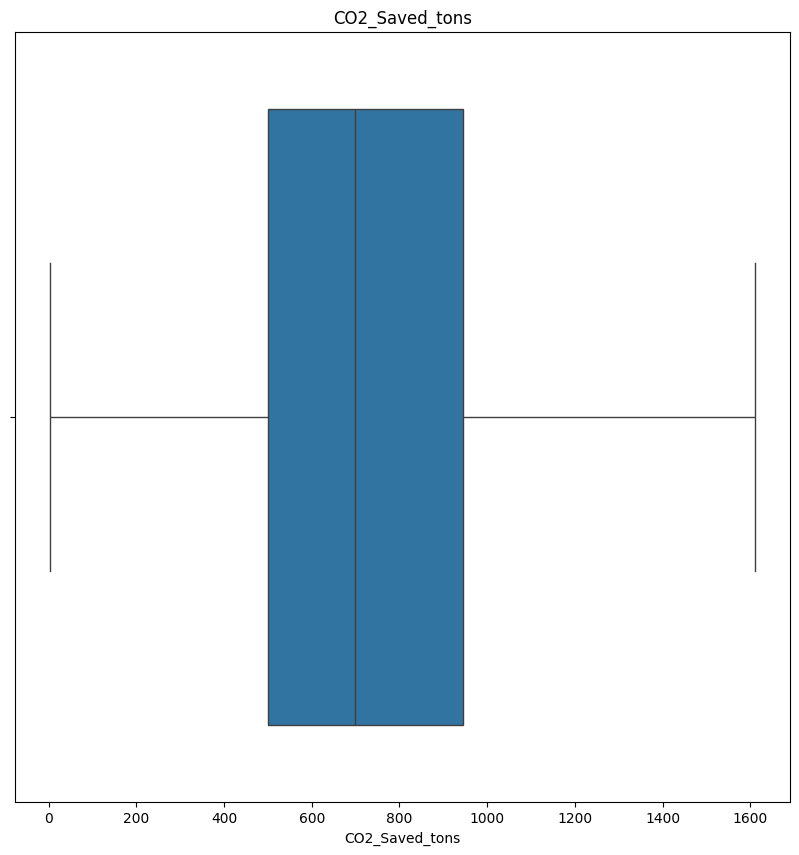

In [166]:
c=["Estimated_Deliveries","Production_Units","CO2_Saved_tons"]
for i in c:
  plt.figure(figsize=(10,10))
  sns.boxplot(x=ev_df[i])
  plt.title(i)
  plt.show()


In [167]:

ev_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646.0,17922.0,92874.27,120,704,1609.9825,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797.0,4164.0,62205.65,75,438,249.4600,Official (Quarter),7640
2,2019,1,North America,Model X,8411.0,9189.0,117887.32,82,480,605.5900,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555.0,7311.0,89294.91,120,712,700.0700,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374.0,13537.0,114846.78,120,661,1226.8800,Estimated (Region),8722


In [168]:
ev_df.corr(numeric_only=True)['Estimated_Deliveries'].sort_values(ascending=False)

,Estimated_Deliveries
Estimated_Deliveries,1.000000
Production_Units,0.994312
CO2_Saved_tons,0.839164
Month,0.030730
Charging_Stations,0.001451
Year,-0.001381
Range_km,-0.006243
Battery_Capacity_kWh,-0.007531
Avg_Price_USD,-0.026679


Distribution of delivery


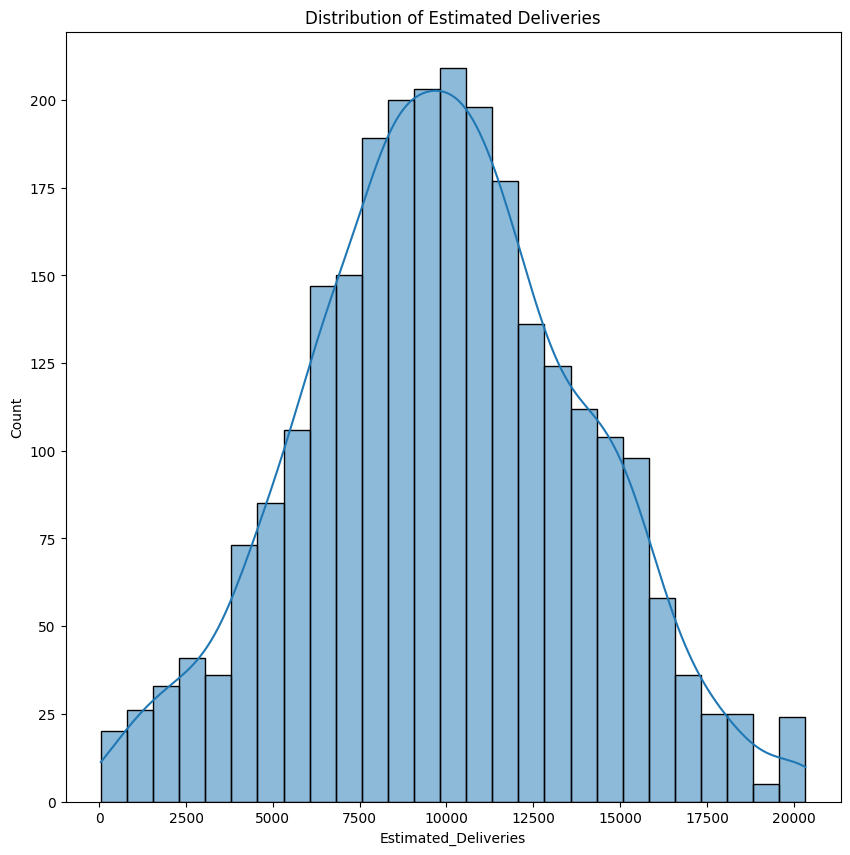

In [169]:
plt.figure(figsize=(10,10))
sns.histplot(ev_df["Estimated_Deliveries"],kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.show()

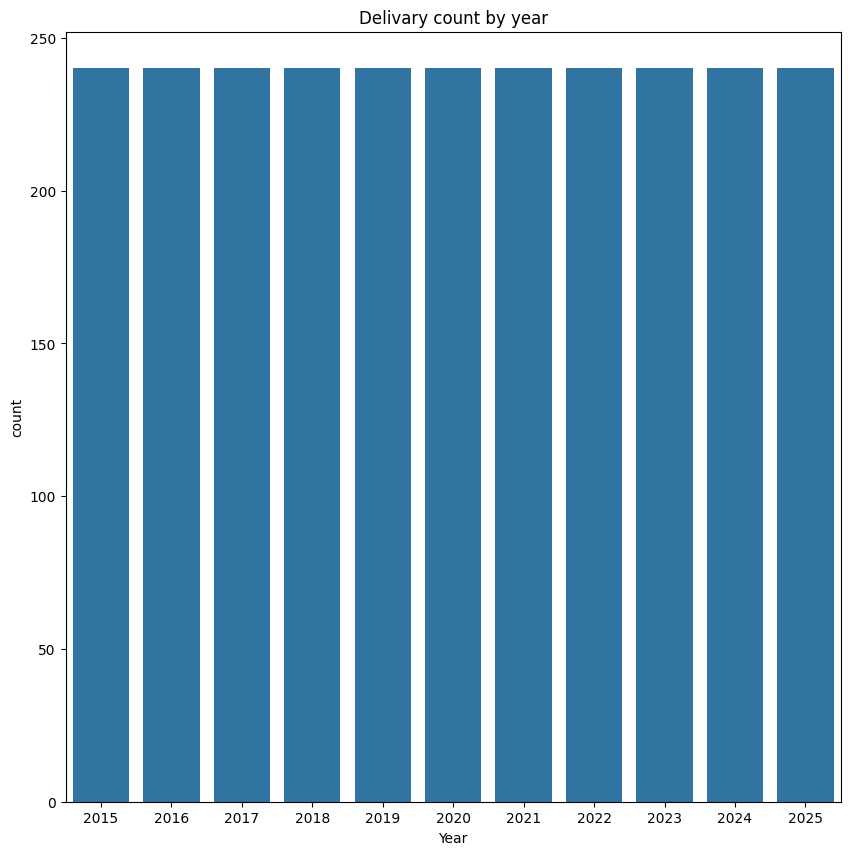

In [170]:
plt.figure(figsize=(10,10))
sns.countplot(x="Year",data=ev_df)
plt.title("Delivary count by year")
plt.show()

Delivery trend over the year

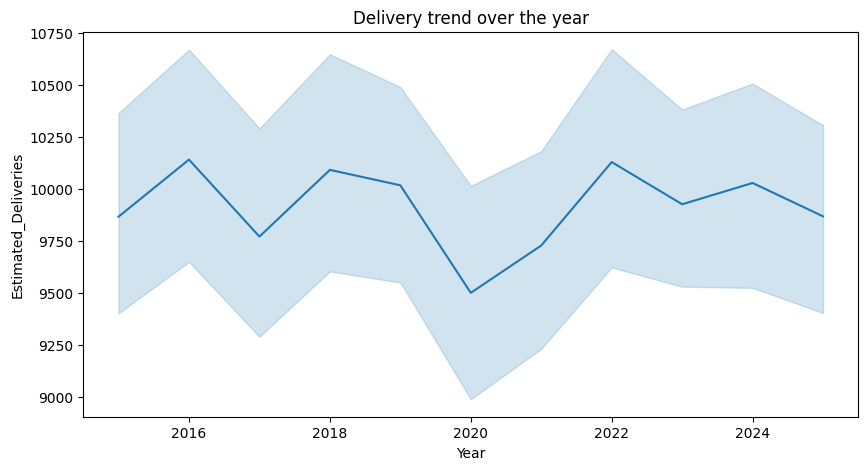

In [171]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Year",y="Estimated_Deliveries",data=ev_df)
plt.title("Delivery trend over the year")
plt.show()

check the graph linear relation


<Figure size 1000x1600 with 0 Axes>

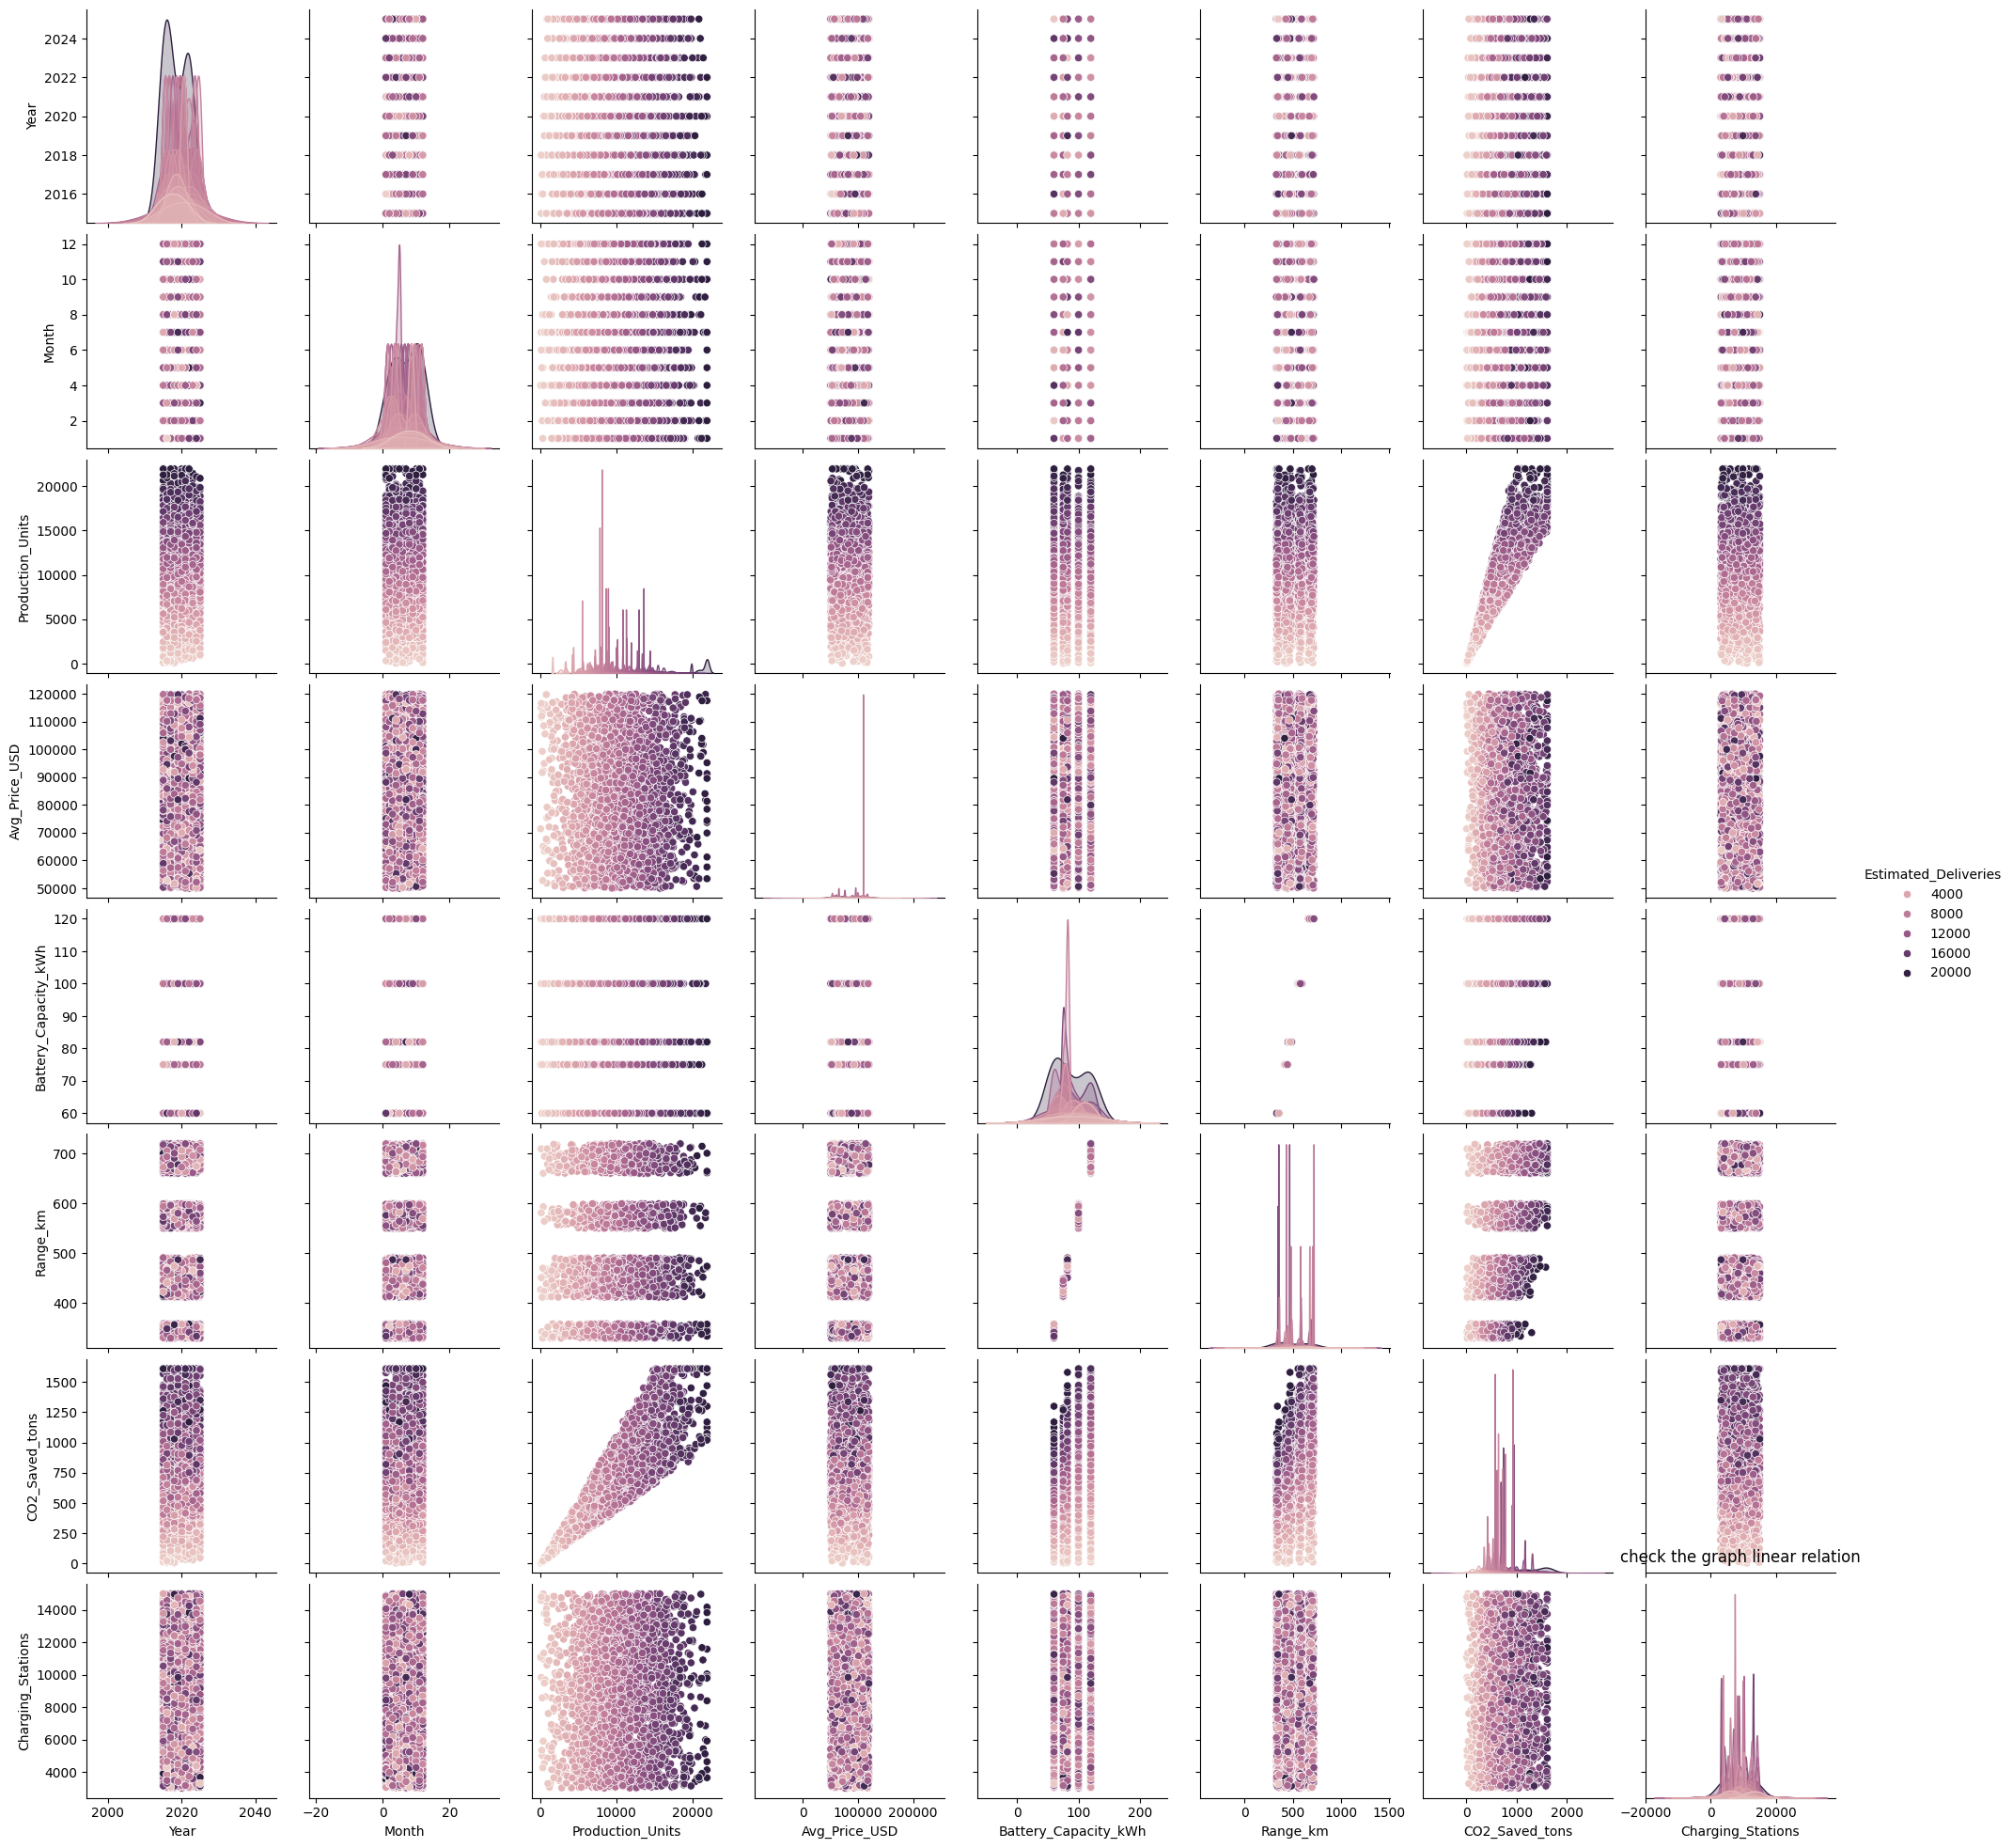

In [172]:
plt.figure(figsize=(10,16))
sns.pairplot(ev_df,hue="Estimated_Deliveries")
plt.title("check the graph linear relation")
plt.show()

price vs deliveries

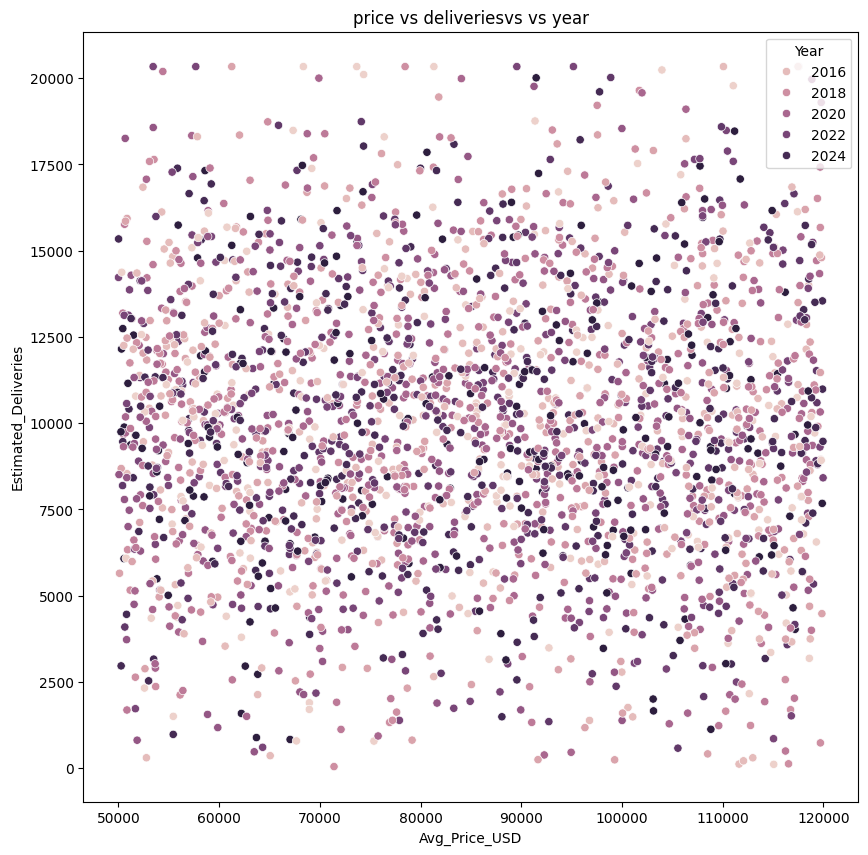

(None,)

In [173]:
plt.figure(figsize=(10,10))
sns.scatterplot(x=ev_df['Avg_Price_USD'],y=ev_df['Estimated_Deliveries'],hue=ev_df['Year'],data=ev_df)
plt.title("price vs deliveriesvs vs year")
plt.show(),


**feature** **engineering**


In [174]:
ev_df["Date"]=pd.to_datetime(ev_df[["Year", "Month"]].assign(DAY=1))

In [175]:
ev_df = ev_df.drop(columns=['Production_Units', 'CO2_Saved_tons'])

# 2. Extract Time Patterns (Seasonality)
ev_df['Quarter'] = ev_df['Month'].apply(lambda x: (x-1)//3 + 1)
ev_df["Price_km"] = (ev_df["Avg_Price_USD"] / ev_df["Range_km"])

# 3. Historical Group Mapping: Har Region aur Model ka past behavior (Mean Deliveries) nikalte hain
# Isme koi leakage nahi hai kyunki ye overall history ka ek constant signature hai
group_mean = ev_df.groupby(['Region', 'Model'])['Estimated_Deliveries'].mean().reset_index()
group_mean.rename(columns={'Estimated_Deliveries': 'Historical_Model_Avg'}, inplace=True)
ev_df = pd.merge(ev_df, group_mean, on=['Region', 'Model'], how='left')

# --- Step 4: Chronological Train-Test Split ---
X = ev_df.drop(columns=["Estimated_Deliveries", "Date"])
y = ev_df['Estimated_Deliveries']

# Time-based split (80% training, 20% testing) - No Shuffling!
split_idx = int(len(ev_df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

###**End to ML Pipe line using regression**


**Train test split**

**encoding and scaling**

In [176]:
cate_cols=["Region", "Model", "Source_Type"]
num_cols=X_train.select_dtypes(include=['int64','float64']).columns

t1=ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cate_cols),("num",RobustScaler(), num_cols)],remainder='passthrough')


**create a pipline**

In [177]:
c=Pipeline(steps=[('preprocess',t1),('model',Lasso())])




**Hyperparameter tuning and model training using lasso**

In [178]:


param_grid = {"model__alpha":[0.01, 0.1, 1, 10, 100,200,300]}
grid = GridSearchCV(c, param_grid,cv=7,scoring="r2")
grid.fit(X_train,y_train)

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type']),
                                                                        ('num',
                                                                         RobustScaler(),
                                                                         Index(['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'Charging_Stations', 'Quarter', 'Price_km', 'Historical_Model_Avg'],
      dtype='object'))])),
                                       ('model', Lasso())]),
             param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 200, 300]},
             scoring='r2')

**evalution of model**

In [179]:
lr_pred=grid.predict(X_test)
print("Lasso Regression Results")
print("mae test:", mean_absolute_error(y_test, lr_pred))
print("mae train:", mean_absolute_error(y_train, grid.predict(X_train)))
print("rmse:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print(r2_score(y_test,grid.predict(X_test)))
print(r2_score(y_train,grid.predict(X_train)))


Lasso Regression Results
mae test: 3081.6297115876832
mae train: 3119.6766829994795
rmse: 3906.123146329777
0.0006319860993385662
0.010458504557121384


In [180]:
c2=Pipeline(steps=[('preprocess',t1),('model',Ridge())])
param = {"model__alpha":[.01, 0.1, 1, 10, 100,200,300]}
grid2 = GridSearchCV(c2, param,cv=7,scoring="r2")
grid2.fit(X_train,y_train)


GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type']),
                                                                        ('num',
                                                                         RobustScaler(),
                                                                         Index(['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'Charging_Stations', 'Quarter', 'Price_km', 'Historical_Model_Avg'],
      dtype='object'))])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 200, 300]},
             scoring='r2')

In [181]:





lr_pred1=grid2.predict(X_test)
print("Ridge Regression Results")
print("mae test:", mean_absolute_error(y_test, lr_pred1))
print("mae train:", mean_absolute_error(y_train, grid2.predict(X_train)))
print("rmse:", np.sqrt(mean_squared_error(y_test, lr_pred1)))
print(r2_score(y_test,grid2.predict(X_test)))
print(r2_score(y_train,grid2.predict(X_train)))
ev_df.corr(numeric_only=True)['Estimated_Deliveries'].sort_values(ascending=False)

Ridge Regression Results
mae test: 3097.7718025116897
mae train: 3108.7002522689017
rmse: 3918.21193136874
-0.005563332984845459
0.015116321284813772


,Estimated_Deliveries
Estimated_Deliveries,1.000000
Historical_Model_Avg,0.094458
Quarter,0.035876
Month,0.030730
Charging_Stations,0.001451
Year,-0.001381
Range_km,-0.006243
Battery_Capacity_kWh,-0.007531
Price_km,-0.019244
Avg_Price_USD,-0.026679


In [182]:
c3=Pipeline(steps=[('preprocess',t1),('model',RandomForestRegressor(random_state=42))])
param3={ "model__n_estimators": [50, 100],"model__max_depth": [5, 10],"model__min_samples_split": [2, 5]}
grid3=GridSearchCV(estimator=c3,param_grid=param3,cv=3,scoring="r2",n_jobs=-1)
grid3.fit(X_train,y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type']),
                                                                        ('num',
                                                                         RobustScaler(),
                                                                         Index(['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'Charging_Stations', 'Quarter', 'Price_km', 'Historical_Model_Avg'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100]},
             scoring='r2')

In [183]:
lr_pred1=grid3.predict(X_test)
print("Random forest regressor")
print("mae test:",mean_absolute_error(y_test, lr_pred1))
print("mae train:",mean_absolute_error(y_train, grid3.predict(X_train)))
print("rmse:", np.sqrt(mean_squared_error(y_test, lr_pred1)))
print(r2_score(y_test,grid3.predict(X_test)))
print(r2_score(y_train,grid3.predict(X_train)))
import pandas as pd

corr = X_train.copy()
corr["target"] = y_train

corr_matrix = corr.corr(numeric_only=True)

print(corr_matrix["target"].sort_values(ascending=False))

Random forest regressor
mae test: 3092.371514399152
mae train: 2950.855080140558
rmse: 3912.721491265336
-0.002747192778992158
0.11845498426244949
target                  1.000000
Historical_Model_Avg    0.107819
Quarter                 0.032749
Month                   0.029103
Year                   -0.003546
Range_km               -0.008113
Battery_Capacity_kWh   -0.009247
Charging_Stations      -0.016088
Price_km               -0.024490
Avg_Price_USD          -0.037225
Name: target, dtype: float64


In [184]:

ts=ev_df.groupby("Date")["Estimated_Deliveries"].sum()
train=ts[:-6]
test=ts[-6:]



In [185]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(ts)
print("p-value:", result[1])

p-value: 1.5239736945206207e-14


In [186]:
train=ts[:-6]
test=ts[-6:]


In [187]:
model=ARIMA(train, order=(1,0,1))
model_fit=model.fit()


In [188]:
forecast=model_fit.forecast(steps=6)

In [189]:
mae=mean_absolute_error(test, forecast)

print("Forecast MAE:", mae)

Forecast MAE: 9286.20764154873
